# Integrate CenterNet landmarks with masked-morphology XGBoost

This notebook demonstrates the complete two-stage inference flow on one frontal radiograph. It first detects and orders vertebral landmarks, deliberately hides one internal detection, and reconstructs its morphology from two vertebrae above and two below.

**Research use only.** This reconstructs observed morphology learned from the current dataset; it is not a clinically validated prediction of healthy anatomy.

## Flow

Frontal image → CenterNet corners → spine-chain ordering → choose an internal gap → four-context features → interpolation baseline → XGBoost residuals → reconstructed morphology → approximate corners.

The simulated mask lets us compare the reconstruction with the landmark model's hidden detection. In a real missing-detection workflow, a separate gap-selection rule must identify which location should be reconstructed.

In [24]:
# If the environment is missing packages, uncomment and run once:
# %pip install -r ../../requirement.txt

## 1. Configuration

Change IMAGE_PATH to inspect another frontal radiograph. TARGET_INDEX is zero-based after superior-to-inferior chain ordering; leave it as None to choose a valid middle vertebra.

In [ ]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import get_ipython
from IPython.display import display
from scipy.optimize import least_squares
from xgboost import XGBRegressor


def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "dataset").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data.build_masked_morphology_dataset import axial_mean_deg, wrap_axial_deg
from src.models.centernet import build_centernet_model
from src.postprocessing.spine_chain import (
    candidates_to_prediction,
    prediction_to_candidates,
    select_spine_chain,
)
from src.predict_centernet import load_checkpoint, predict_image

# predict_centernet uses the headless Agg backend for its CLI. Switch back
# to Jupyter's inline renderer so figures appear below notebook cells.
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

LANDMARK_CHECKPOINT = REPO_ROOT / "src/weights/w18_lumos/best_center_f1.pt"
XGBOOST_DIR = REPO_ROOT / "outputs/masked_morphology/xgboost_four_context_v1"
IMAGE_PATH = REPO_ROOT / "dataset/processed/coco_nih_lumos/test/images/mendeley_pa/MENDE-PA-00024.jpg"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PEAK_THRESHOLD = 0.10
TARGET_INDEX = None
MIN_CONTEXT_SCORE = 0.18

print("Device:", DEVICE)
print("Image:", IMAGE_PATH)
print("Landmark checkpoint:", LANDMARK_CHECKPOINT)
print("XGBoost artifacts:", XGBOOST_DIR)

Device: cpu
Image: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening\dataset\processed\coco_nih_lumos\test\images\buu_ap\BUU-AP-00010.jpg
Landmark checkpoint: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening\src\weights\w18_lumos\best_center_f1.pt
XGBoost artifacts: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening\outputs\masked_morphology\xgboost_four_context_v1


## 2. Load both models

CenterNet produces canonical corners in the order top-left, top-right, bottom-left, bottom-right. Five XGBoost regressors predict corrections for left height, right height, superior width, inferior width, and orientation.

In [26]:
checkpoint = load_checkpoint(LANDMARK_CHECKPOINT, DEVICE)
landmark_args = checkpoint.get("args", {})
BACKBONE = str(landmark_args.get("backbone", "hrnet_w18"))
INPUT_SIZE = int(landmark_args.get("input_size", 1024))
DOWN_RATIO = int(landmark_args.get("down_ratio", 4))
TOPK = int(landmark_args.get("eval_topk", 100))

landmark_model = build_centernet_model(backbone=BACKBONE, pretrained=False)
landmark_model.load_state_dict(checkpoint["model_state_dict"], strict=True)
landmark_model.to(DEVICE).eval()

with (XGBOOST_DIR / "run_manifest.json").open("r", encoding="utf-8") as file:
    xgb_manifest = json.load(file)
feature_columns = list(xgb_manifest["feature_columns"])
output_names = [
    "left_height", "right_height", "superior_width",
    "inferior_width", "orientation",
]
xgb_models = {}
for name in output_names:
    model = XGBRegressor()
    model.load_model(XGBOOST_DIR / "models" / f"{name}.json")
    xgb_models[name] = model

print(f"CenterNet: {BACKBONE}, input={INPUT_SIZE}, down ratio={DOWN_RATIO}")
print(f"XGBoost: {len(xgb_models)} models, {len(feature_columns)} ordered inputs")

CenterNet: hrnet_w18, input=1024, down ratio=4
XGBoost: 5 models, 28 ordered inputs


## 3. Run landmark detection and spine-chain selection

Raw detections are deduplicated and filtered into one superior-to-inferior spine chain. At least five chain detections are required to simulate masking an internal target.

In [27]:
image_rgb, heatmap, raw_prediction, transform_meta = predict_image(
    model=landmark_model,
    image_path=IMAGE_PATH,
    device=DEVICE,
    input_size=INPUT_SIZE,
    down_ratio=DOWN_RATIO,
    peak_thresh=PEAK_THRESHOLD,
    topk=TOPK,
)

raw_candidates = prediction_to_candidates(raw_prediction)
deduplicated, chain, chain_debug = select_spine_chain(
    raw_candidates,
    score_threshold=MIN_CONTEXT_SCORE,
    min_chain_len=5,
)
if len(chain) < 5:
    raise RuntimeError(
        f"Only {len(chain)} ordered vertebrae were detected; four-context reconstruction needs at least 5."
    )

chain_table = pd.DataFrame([
    {
        "chain_index": index,
        "score": candidate.score,
        "center_x": candidate.center[0],
        "center_y": candidate.center[1],
    }
    for index, candidate in enumerate(chain)
])
display(chain_table.round(3))
print("Chain audit:", chain_debug)

,chain_index,score,center_x,center_y
0,0,0.300,747.591003,353.885986
1,1,0.887,745.653992,525.166016
2,2,0.893,765.966003,696.580994
3,3,0.929,860.372986,885.903992
4,4,0.879,916.825012,1075.012939
5,5,0.698,926.955017,1236.905029


Chain audit: {'score': 10.224147086202153, 'target_dy': 171.41534423828125, 'min_dy': 59.99537048339843, 'max_dy': 359.97222290039065, 'node_score_threshold': 0.18, 'num_candidates': 6, 'num_selected': 6, 'num_raw': 6, 'num_deduplicated': 6}


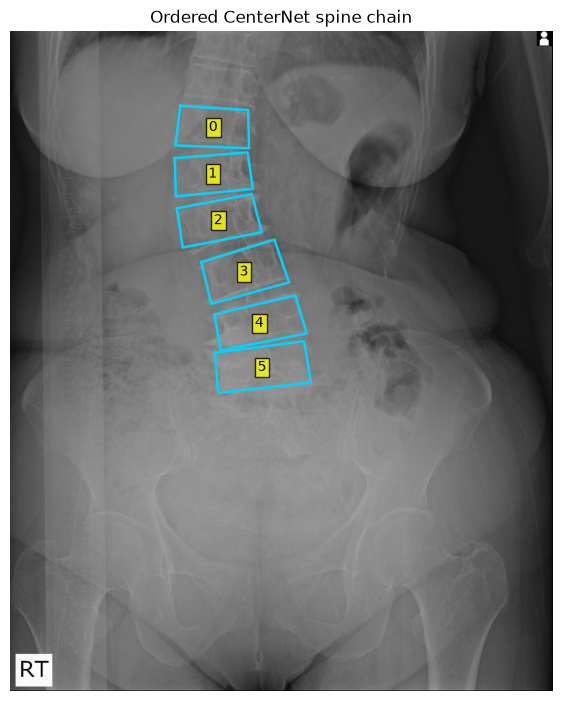

In [28]:
fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(image_rgb)
for index, candidate in enumerate(chain):
    polygon = candidate.corners[[0, 1, 3, 2, 0]]
    ax.plot(polygon[:, 0], polygon[:, 1], color="#00d4ff", linewidth=1.8)
    ax.text(
        candidate.center[0], candidate.center[1], str(index),
        color="black", ha="center", va="center",
        bbox={"facecolor": "yellow", "alpha": 0.8, "pad": 2},
    )
ax.set_title("Ordered CenterNet spine chain")
ax.axis("off")
plt.show()

## 4. Hide one target and construct the exact training features

Only offsets m2, m1, p1, and p2 enter the feature builder. The hidden target is used later only for comparison, never as an XGBoost input.

In [29]:
def line_angle_deg(first, second):
    vector = np.asarray(second, dtype=float) - np.asarray(first, dtype=float)
    return float(wrap_axial_deg(math.degrees(math.atan2(vector[1], vector[0]))))


def morphology_from_corners(corners):
    points = np.asarray(corners, dtype=float)
    if points.shape != (4, 2) or not np.isfinite(points).all():
        raise ValueError("Expected four finite corners in TL, TR, BL, BR order.")
    tl, tr, bl, br = points
    distance = lambda a, b: float(np.linalg.norm(b - a))
    superior_angle = line_angle_deg(tl, tr)
    inferior_angle = line_angle_deg(bl, br)
    return {
        "center_x": float(points[:, 0].mean()),
        "center_y": float(points[:, 1].mean()),
        "left_height": distance(tl, bl),
        "right_height": distance(tr, br),
        "superior_width": distance(tl, tr),
        "inferior_width": distance(bl, br),
        "orientation": axial_mean_deg(superior_angle, inferior_angle),
    }


def build_four_context_features(context):
    expected_offsets = {-2, -1, 1, 2}
    if set(context) != expected_offsets:
        raise ValueError(f"Context offsets must be {sorted(expected_offsets)}.")
    measured = {
        offset: morphology_from_corners(candidate.corners)
        for offset, candidate in context.items()
    }
    reference_height = float(np.median([
        0.5 * (row["left_height"] + row["right_height"])
        for row in measured.values()
    ]))
    reference_width = float(np.median([
        0.5 * (row["superior_width"] + row["inferior_width"])
        for row in measured.values()
    ]))
    if reference_height <= 0 or reference_width <= 0:
        raise ValueError("Context produced a nonpositive reference scale.")

    upper, lower = measured[-1], measured[1]
    anchor = np.array([
        0.5 * (upper["center_x"] + lower["center_x"]),
        0.5 * (upper["center_y"] + lower["center_y"]),
    ])
    baseline_orientation = axial_mean_deg(upper["orientation"], lower["orientation"])

    row = {}
    for offset in (-2, -1, 1, 2):
        prefix = f"x_{'m' + str(abs(offset)) if offset < 0 else 'p' + str(offset)}"
        item = measured[offset]
        row[f"{prefix}_left_height_norm"] = item["left_height"] / reference_height
        row[f"{prefix}_right_height_norm"] = item["right_height"] / reference_height
        row[f"{prefix}_superior_width_norm"] = item["superior_width"] / reference_width
        row[f"{prefix}_inferior_width_norm"] = item["inferior_width"] / reference_width
        row[f"{prefix}_orientation_relative_deg"] = float(
            wrap_axial_deg(item["orientation"] - baseline_orientation)
        )
        row[f"{prefix}_center_dx_norm"] = (item["center_x"] - anchor[0]) / reference_width
        row[f"{prefix}_center_dy_norm"] = (item["center_y"] - anchor[1]) / reference_height

    features = pd.DataFrame([row]).reindex(columns=feature_columns)
    if features.isna().any().any():
        missing = features.columns[features.isna().any()].tolist()
        raise ValueError(f"Missing inference features: {missing}")
    state = {
        "measured": measured,
        "reference_height": reference_height,
        "reference_width": reference_width,
        "anchor": anchor,
        "baseline_orientation": baseline_orientation,
    }
    return features, state

In [30]:
if TARGET_INDEX is None:
    target_index = min(max(len(chain) // 2, 2), len(chain) - 3)
else:
    target_index = int(TARGET_INDEX)
if not 2 <= target_index <= len(chain) - 3:
    raise ValueError("TARGET_INDEX needs two vertebrae above and two below.")

hidden_target = chain[target_index]
context = {
    -2: chain[target_index - 2],
    -1: chain[target_index - 1],
     1: chain[target_index + 1],
     2: chain[target_index + 2],
}
if min(candidate.score for candidate in context.values()) < MIN_CONTEXT_SCORE:
    raise RuntimeError("At least one context landmark is below the confidence gate.")

X_inference, context_state = build_four_context_features(context)
display(X_inference.T.rename(columns={0: "value"}).round(4))
print("Hidden chain index:", target_index)
print("Reference height/width:", round(context_state["reference_height"], 2), round(context_state["reference_width"], 2))
print("Interpolated center:", context_state["anchor"].round(2))

,value
x_m2_left_height_norm,0.9859
x_m2_right_height_norm,0.9504
x_m2_superior_width_norm,0.8915
x_m2_inferior_width_norm,0.9451
x_m2_orientation_relative_deg,6.5045
x_m2_center_dx_norm,-0.3180
x_m2_center_dy_norm,-2.5248
x_m1_left_height_norm,1.0188
x_m1_right_height_norm,1.0147
x_m1_superior_width_norm,0.9329


Hidden chain index: 3
Reference height/width: 142.88 301.28
Interpolated center: [841.38 885.89]


## 5. Predict the masked morphology

The interpolation baseline comes from the nearest superior and inferior vertebrae. XGBoost predicts a residual correction to that baseline.

In [31]:
predicted_residuals = {
    name: float(model.predict(X_inference)[0])
    for name, model in xgb_models.items()
}

upper = context_state["measured"][-1]
lower = context_state["measured"][1]
predicted_morphology = {}
baseline_morphology = {}
for name in ("left_height", "right_height", "superior_width", "inferior_width"):
    scale = (
        context_state["reference_height"] if "height" in name
        else context_state["reference_width"]
    )
    baseline_px = 0.5 * (upper[name] + lower[name])
    baseline_morphology[name] = baseline_px
    predicted_morphology[name] = baseline_px + predicted_residuals[name] * scale

baseline_morphology["orientation"] = context_state["baseline_orientation"]
predicted_morphology["orientation"] = float(wrap_axial_deg(
    context_state["baseline_orientation"] + predicted_residuals["orientation"]
))
predicted_morphology["center_x"] = float(context_state["anchor"][0])
predicted_morphology["center_y"] = float(context_state["anchor"][1])

if min(predicted_morphology[name] for name in output_names[:-1]) <= 0:
    raise RuntimeError("XGBoost produced a nonpositive dimension; reject this reconstruction.")

hidden_morphology = morphology_from_corners(hidden_target.corners)
comparison = pd.DataFrame({
    "interpolation": baseline_morphology,
    "xgboost": predicted_morphology,
    "hidden_landmark_detection": hidden_morphology,
}).loc[output_names]
comparison["xgboost_absolute_error"] = (
    comparison["xgboost"] - comparison["hidden_landmark_detection"]
).abs()
display(comparison.round(3))
display(pd.Series(predicted_residuals, name="predicted_residual").to_frame().round(4))

,interpolation,xgboost,hidden_landmark_detection,xgboost_absolute_error
left_height,140.086,153.586,158.031,4.445
right_height,145.671,151.707,166.094,14.386
superior_width,293.274,293.836,281.650,12.187
inferior_width,309.281,311.692,296.941,14.751
orientation,-11.534,-13.302,-16.294,2.993


,predicted_residual
left_height,0.0945
right_height,0.0422
superior_width,0.0019
inferior_width,0.0080
orientation,-1.7675


## 6. Fit a plausible corner shape for visualization

Five morphology values do not uniquely determine four corners. To resolve the missing shape degree of freedom without creating a sheared wedge, the fitter averages the normalized shapes of the nearest superior and inferior vertebrae, then uses constrained least squares to match the predicted dimensions, center, and orientation. Invalid geometry is rejected. The morphology table remains the primary model output.

In [32]:
def rotation_matrix(angle_deg):
    angle = math.radians(float(angle_deg))
    return np.array([
        [math.cos(angle), -math.sin(angle)],
        [math.sin(angle),  math.cos(angle)],
    ])


def normalized_local_shape(candidate):
    item = morphology_from_corners(candidate.corners)
    center = np.array([item["center_x"], item["center_y"]])
    mean_width = 0.5 * (item["superior_width"] + item["inferior_width"])
    mean_height = 0.5 * (item["left_height"] + item["right_height"])
    local = (np.asarray(candidate.corners) - center) @ rotation_matrix(item["orientation"])
    return local / np.array([mean_width, mean_height])


def quadrilateral_is_valid(points):
    points = np.asarray(points, dtype=float)
    if points.shape != (4, 2) or not np.isfinite(points).all():
        return False
    polygon = points[[0, 1, 3, 2]]
    edges = np.roll(polygon, -1, axis=0) - polygon
    next_edges = np.roll(edges, -1, axis=0)
    crosses = edges[:, 0] * next_edges[:, 1] - edges[:, 1] * next_edges[:, 0]
    if not (np.all(crosses > 1e-6) or np.all(crosses < -1e-6)):
        return False
    return bool(
        points[[0, 1], 1].mean() < points[[2, 3], 1].mean()
        and points[[0, 2], 0].mean() < points[[1, 3], 0].mean()
    )


def morphology_to_template_fitted_corners(morphology, context):
    target_center = np.array([morphology["center_x"], morphology["center_y"]], dtype=float)
    target_width = 0.5 * (morphology["superior_width"] + morphology["inferior_width"])
    target_height = 0.5 * (morphology["left_height"] + morphology["right_height"])
    scale = np.array([target_width, target_height], dtype=float)
    if np.any(scale <= 0):
        raise ValueError("Nonpositive target scale")

    # The nearest neighbors provide the missing trapezoid/endplate shape information.
    template_normalized = 0.5 * (
        normalized_local_shape(context[-1]) + normalized_local_shape(context[1])
    )
    template_local = template_normalized * scale
    template_local -= template_local.mean(axis=0, keepdims=True)

    def objective(flat_points):
        points = flat_points.reshape(4, 2)
        tl, tr, bl, br = points
        measured = {
            "left_height": np.linalg.norm(bl - tl),
            "right_height": np.linalg.norm(br - tr),
            "superior_width": np.linalg.norm(tr - tl),
            "inferior_width": np.linalg.norm(br - bl),
        }
        residuals = [
            4.0 * (measured["left_height"] - morphology["left_height"]) / target_height,
            4.0 * (measured["right_height"] - morphology["right_height"]) / target_height,
            4.0 * (measured["superior_width"] - morphology["superior_width"]) / target_width,
            4.0 * (measured["inferior_width"] - morphology["inferior_width"]) / target_width,
            5.0 * points[:, 0].mean() / target_width,
            5.0 * points[:, 1].mean() / target_height,
        ]
        superior_angle = line_angle_deg(tl, tr)
        inferior_angle = line_angle_deg(bl, br)
        local_orientation = axial_mean_deg(superior_angle, inferior_angle)
        residuals.append(float(wrap_axial_deg(local_orientation)) / 2.0)
        residuals.extend((0.35 * (points - template_local) / scale).ravel())
        # Soft barriers preserve canonical TL, TR, BL, BR semantics.
        residuals.extend([
            8.0 * max(0.0, (points[[0, 1], 1].mean() - points[[2, 3], 1].mean()) / target_height),
            8.0 * max(0.0, (points[[0, 2], 0].mean() - points[[1, 3], 0].mean()) / target_width),
        ])
        return np.asarray(residuals, dtype=float)

    fit = least_squares(objective, template_local.ravel(), max_nfev=600)
    fitted_local = fit.x.reshape(4, 2)
    fitted_world = fitted_local @ rotation_matrix(morphology["orientation"]).T + target_center
    if not fit.success or not quadrilateral_is_valid(fitted_world):
        raise ValueError("Corner fit failed the geometry validity gate")

    fitted_morphology = morphology_from_corners(fitted_world)
    relative_errors = []
    for name in ("left_height", "right_height", "superior_width", "inferior_width"):
        relative_errors.append(abs(fitted_morphology[name] - morphology[name]) / morphology[name])
    orientation_error = abs(float(wrap_axial_deg(
        fitted_morphology["orientation"] - morphology["orientation"]
    )))
    diagnostics = {
        "fit_success": bool(fit.success),
        "max_dimension_relative_error": max(relative_errors),
        "orientation_error_deg": orientation_error,
        "optimizer_cost": float(fit.cost),
    }
    if diagnostics["max_dimension_relative_error"] > 0.10 or orientation_error > 2.0:
        raise ValueError(f"Corner fit is inconsistent with predicted morphology: {diagnostics}")
    return fitted_world, diagnostics


reconstructed_corners, reconstruction_diagnostics = morphology_to_template_fitted_corners(
    predicted_morphology, context
)
reconstructed_check = morphology_from_corners(reconstructed_corners)
display(pd.DataFrame({
    "requested": predicted_morphology,
    "corner_approximation": reconstructed_check,
}).loc[output_names].round(3))
print("Geometry fit:", reconstruction_diagnostics)

,requested,corner_approximation
left_height,153.586,153.571
right_height,151.707,151.722
superior_width,293.836,293.840
inferior_width,311.692,311.688
orientation,-13.302,-13.302


Geometry fit: {'fit_success': True, 'max_dimension_relative_error': 9.913952349349486e-05, 'orientation_error_deg': 1.1818832220455988e-05, 'optimizer_cost': 4.14365020909002e-05}


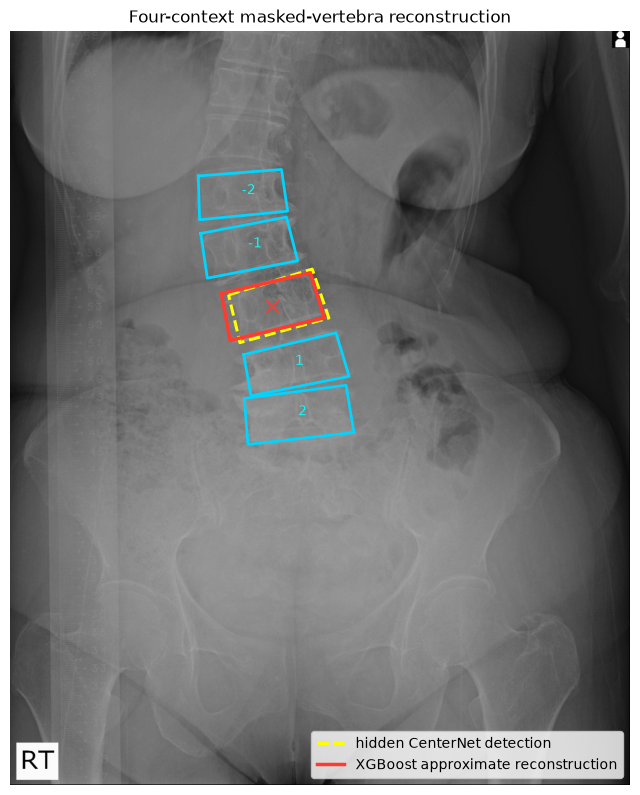

In [33]:
fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(image_rgb)

for offset, candidate in context.items():
    polygon = candidate.corners[[0, 1, 3, 2, 0]]
    ax.plot(polygon[:, 0], polygon[:, 1], color="#00d4ff", linewidth=2)
    ax.text(candidate.center[0], candidate.center[1], str(offset), color="cyan")

actual_polygon = hidden_target.corners[[0, 1, 3, 2, 0]]
predicted_polygon = reconstructed_corners[[0, 1, 3, 2, 0]]
ax.plot(
    actual_polygon[:, 0], actual_polygon[:, 1],
    color="yellow", linestyle="--", linewidth=2.2,
    label="hidden CenterNet detection",
)
ax.plot(
    predicted_polygon[:, 0], predicted_polygon[:, 1],
    color="#ff3b30", linewidth=2.5,
    label="XGBoost approximate reconstruction",
)
ax.scatter(
    [predicted_morphology["center_x"]], [predicted_morphology["center_y"]],
    marker="x", s=80, color="#ff3b30",
)
ax.set_title("Four-context masked-vertebra reconstruction")
ax.legend(loc="lower right")
ax.axis("off")
plt.show()

## 7. Run multiple demonstrations

This section runs several radiographs and reconstructs several eligible internal targets in each image. The targets are still simulated masks, so their original CenterNet corners remain available only for technical comparison.

In [34]:
BATCH_IMAGE_DIR = REPO_ROOT / "dataset/processed/coco_nih_lumos/test/images"
BATCH_IMAGE_LIMIT = 4
BATCH_TARGETS_PER_IMAGE = 2

BATCH_IMAGE_PATHS = sorted(
    path for path in BATCH_IMAGE_DIR.rglob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
)[:BATCH_IMAGE_LIMIT]
print(f"Selected {len(BATCH_IMAGE_PATHS)} images")
for path in BATCH_IMAGE_PATHS:
    print(" -", path.relative_to(REPO_ROOT))

Selected 4 images
 - dataset\processed\coco_nih_lumos\test\images\buu_ap\BUU-AP-00010.jpg
 - dataset\processed\coco_nih_lumos\test\images\buu_ap\BUU-AP-00013.jpg
 - dataset\processed\coco_nih_lumos\test\images\buu_ap\BUU-AP-00020.jpg
 - dataset\processed\coco_nih_lumos\test\images\buu_ap\BUU-AP-00023.jpg


In [35]:
def predict_morphology_from_context(context):
    features, state = build_four_context_features(context)
    residuals = {
        name: float(model.predict(features)[0])
        for name, model in xgb_models.items()
    }
    upper, lower = state["measured"][-1], state["measured"][1]
    baseline = {}
    predicted = {}
    for name in ("left_height", "right_height", "superior_width", "inferior_width"):
        scale = state["reference_height"] if "height" in name else state["reference_width"]
        baseline[name] = 0.5 * (upper[name] + lower[name])
        predicted[name] = baseline[name] + residuals[name] * scale
    baseline["orientation"] = state["baseline_orientation"]
    predicted["orientation"] = float(wrap_axial_deg(
        state["baseline_orientation"] + residuals["orientation"]
    ))
    predicted["center_x"] = float(state["anchor"][0])
    predicted["center_y"] = float(state["anchor"][1])
    if min(predicted[name] for name in output_names[:-1]) <= 0:
        raise ValueError("Predicted a nonpositive morphology dimension.")
    return predicted, baseline, residuals, state


def evenly_spaced_targets(eligible, limit):
    if limit is None or len(eligible) <= limit:
        return eligible
    positions = np.linspace(0, len(eligible) - 1, limit).round().astype(int)
    return [eligible[index] for index in dict.fromkeys(positions)]

In [36]:
batch_rows = []
batch_examples = []
batch_skipped = []

for batch_image_path in BATCH_IMAGE_PATHS:
    batch_rgb, _, batch_raw_prediction, _ = predict_image(
        model=landmark_model,
        image_path=batch_image_path,
        device=DEVICE,
        input_size=INPUT_SIZE,
        down_ratio=DOWN_RATIO,
        peak_thresh=PEAK_THRESHOLD,
        topk=TOPK,
    )
    batch_candidates = prediction_to_candidates(batch_raw_prediction)
    _, batch_chain, batch_debug = select_spine_chain(
        batch_candidates,
        score_threshold=MIN_CONTEXT_SCORE,
        min_chain_len=5,
    )
    if len(batch_chain) < 5:
        batch_skipped.append({
            "image": batch_image_path.name,
            "reason": f"only {len(batch_chain)} chain detections",
        })
        continue

    eligible_targets = list(range(2, len(batch_chain) - 2))
    selected_targets = evenly_spaced_targets(eligible_targets, BATCH_TARGETS_PER_IMAGE)
    for batch_target_index in selected_targets:
        batch_context = {
            -2: batch_chain[batch_target_index - 2],
            -1: batch_chain[batch_target_index - 1],
             1: batch_chain[batch_target_index + 1],
             2: batch_chain[batch_target_index + 2],
        }
        minimum_score = min(candidate.score for candidate in batch_context.values())
        if minimum_score < MIN_CONTEXT_SCORE:
            batch_skipped.append({
                "image": batch_image_path.name,
                "reason": f"target {batch_target_index}: low context confidence",
            })
            continue

        try:
            batch_morphology, batch_baseline, _, _ = predict_morphology_from_context(batch_context)
            batch_corners, batch_fit = morphology_to_template_fitted_corners(
                batch_morphology, batch_context
            )
        except ValueError as error:
            batch_skipped.append({
                "image": batch_image_path.name,
                "reason": f"target {batch_target_index}: {error}",
            })
            continue

        batch_hidden = batch_chain[batch_target_index]
        batch_actual = morphology_from_corners(batch_hidden.corners)
        row = {
            "image": batch_image_path.name,
            "chain_count": len(batch_chain),
            "target_index": batch_target_index,
            "min_context_score": minimum_score,
            "corner_fit_max_relative_error": batch_fit["max_dimension_relative_error"],
            "center_error_px": float(np.linalg.norm(
                np.array([batch_morphology["center_x"], batch_morphology["center_y"]])
                - np.array([batch_actual["center_x"], batch_actual["center_y"]])
            )),
        }
        for name in output_names:
            difference = batch_morphology[name] - batch_actual[name]
            if name == "orientation":
                difference = float(wrap_axial_deg(difference))
            row[f"{name}_absolute_error"] = abs(float(difference))
        batch_rows.append(row)
        batch_examples.append({
            "image": batch_image_path.name,
            "image_rgb": batch_rgb,
            "target_index": batch_target_index,
            "context": batch_context,
            "hidden_corners": batch_hidden.corners,
            "predicted_corners": batch_corners,
        })

batch_results = pd.DataFrame(batch_rows)
display(batch_results.round(3))
print(f"Completed {len(batch_results)} reconstructions across {batch_results['image'].nunique() if len(batch_results) else 0} images.")
if batch_skipped:
    print("Skipped cases:")
    display(pd.DataFrame(batch_skipped))

,image,chain_count,target_index,min_context_score,corner_fit_max_relative_error,center_error_px,left_height_absolute_error,right_height_absolute_error,superior_width_absolute_error,inferior_width_absolute_error,orientation_absolute_error
0,BUU-AP-00010.jpg,6,2,0.300,0.0,38.105,2.310,1.398,4.817,6.129,1.290
1,BUU-AP-00010.jpg,6,3,0.698,0.0,18.928,4.445,14.386,12.187,14.751,2.993
2,BUU-AP-00013.jpg,6,2,0.529,0.0,16.118,19.461,6.548,26.851,21.108,0.959
3,BUU-AP-00023.jpg,5,2,0.829,0.0,2.105,1.340,2.503,1.369,2.176,0.691


Completed 4 reconstructions across 3 images.
Skipped cases:


,image,reason
0,BUU-AP-00013.jpg,target 3: low context confidence
1,BUU-AP-00020.jpg,only 4 chain detections


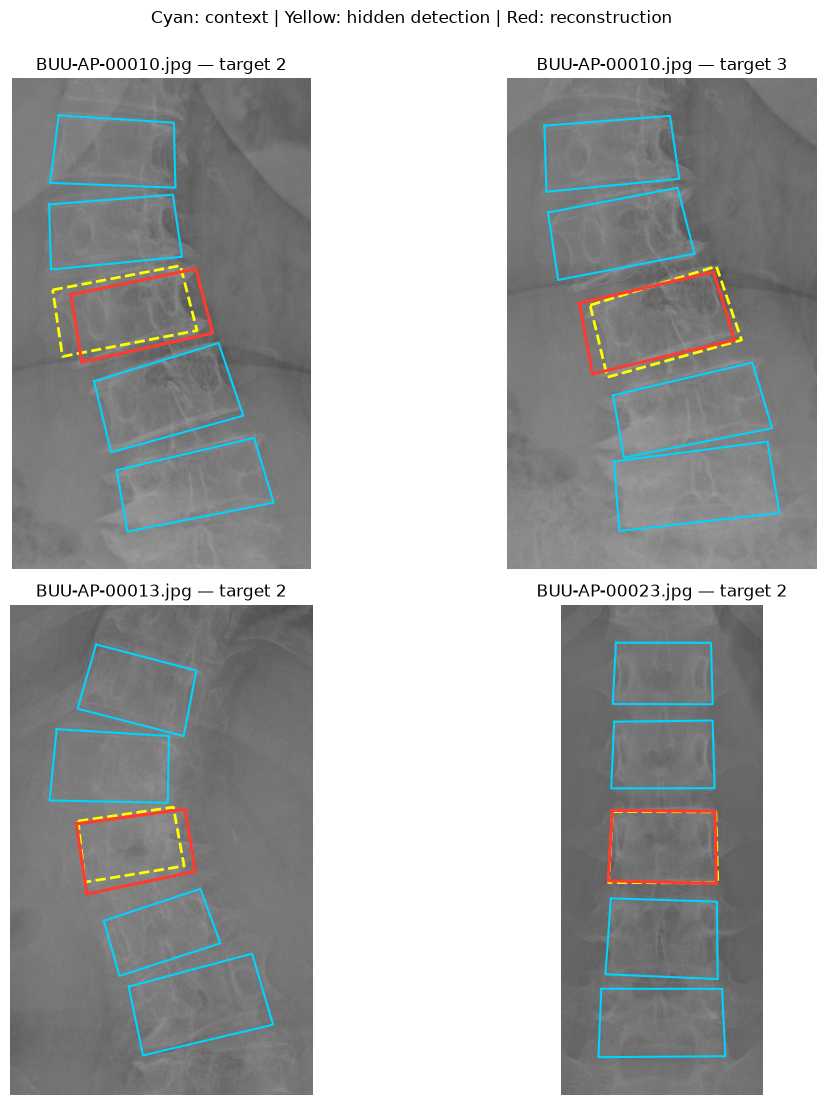

In [37]:
if batch_examples:
    columns = 2
    rows = math.ceil(len(batch_examples) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(12, 5.5 * rows), squeeze=False)
    for ax, example in zip(axes.flat, batch_examples):
        ax.imshow(example["image_rgb"])
        all_points = []
        for candidate in example["context"].values():
            polygon = candidate.corners[[0, 1, 3, 2, 0]]
            ax.plot(polygon[:, 0], polygon[:, 1], color="#00d4ff", linewidth=1.5)
            all_points.append(candidate.corners)
        hidden_polygon = example["hidden_corners"][[0, 1, 3, 2, 0]]
        predicted_polygon = example["predicted_corners"][[0, 1, 3, 2, 0]]
        ax.plot(hidden_polygon[:, 0], hidden_polygon[:, 1], "--", color="yellow", linewidth=2)
        ax.plot(predicted_polygon[:, 0], predicted_polygon[:, 1], color="#ff3b30", linewidth=2.2)
        all_points.extend([example["hidden_corners"], example["predicted_corners"]])
        points = np.concatenate(all_points)
        padding = 80
        ax.set_xlim(points[:, 0].min() - padding, points[:, 0].max() + padding)
        ax.set_ylim(points[:, 1].max() + padding, points[:, 1].min() - padding)
        ax.set_title(f"{example['image']} — target {example['target_index']}")
        ax.axis("off")
    for ax in axes.flat[len(batch_examples):]:
        ax.axis("off")
    fig.suptitle("Cyan: context | Yellow: hidden detection | Red: reconstruction", y=1.0)
    plt.tight_layout()
    plt.show()

## 8. Deployment handoff

For a real missing detection, supply four already ordered candidates as {-2: upper-two, -1: upper-one, 1: lower-one, 2: lower-two} to build_four_context_features. Keep these gates:

- require all four context detections and acceptable landmark confidence;
- use the same canonical corner order and the exact manifest feature order;
- reject nonfinite or nonpositive morphology outputs;
- report the interpolation center separately from the learned shape;
- do not infer a missing level solely from a large spacing gap without validating a dedicated gap-selection method;
- retain the original detections, scores, model versions, and reconstructed result for auditing.